# Relationship between Duration of the Concept and International Collaboration

The code here is used for calculating the relationship between the duration of concepts and the international collaboration at the time it was proposed.

Running this code requires the `subtree_csv` folder generated by EX1. Please note that you need to modify and run it according to the prompts in EX1 before running this file.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt


def inverted_index_to_abstract(paper_json: dict) -> None:
    """Turn inverted index in json into raw abstract.

    Args:
        paper_json (dict): json in each line of works.txt in OpenAlex dataset.
    """
    inverted_index = paper_json["abstract_inverted_index"]
    # Deal with works like https://openalex.org/W4247653807
    if (
        inverted_index is None
        or inverted_index == {}
        or len(paper_json["authorships"]) == 0
    ):
        paper_json["abstract"] = None
        return
    max_index = max(
        index for word_index in inverted_index.values() for index in word_index
    )
    sentence_list = [""] * (max_index + 1)
    for word, word_index in inverted_index.items():
        for index in word_index:
            sentence_list[index] = word
    paper_abstract = " ".join(sentence_list)
    if paper_abstract == "No abstract available.":
        paper_json["abstract"] = None
        return
    if paper_abstract == "No disponible":
        paper_json["abstract"] = None
        return
    if paper_abstract.startswith("An abstract is not available for this content"):
        paper_json["abstract"] = None
        return
    paper_json["abstract"] = paper_abstract


def import_data(filename: str) -> dict:
    all_papers_dict = {}
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            paper_json = json.loads(line)
            inverted_index_to_abstract(paper_json)
            if paper_json["abstract"] is None:
                continue
            all_papers_dict[paper_json["id"]] = paper_json
    return all_papers_dict


def import_subtree(dir: str) -> pd.DataFrame:
    subtree = []
    for path in os.listdir(dir):
        subtree.append(pd.read_csv(os.path.join(dir, path), index_col=None))
    df = pd.concat(subtree, ignore_index=True)
    return df

In [2]:
def calculate_status(row):
    if row["countries_distinct_count"] >= 2:
        return "international"
    elif row["institutions_distinct_count"] >= 2:
        return "national"
    else:
        return "local"


def get_type(name: str):
    subtree_dir = f"./subtree_csv_{name}"
    dataset = f"./openalex_data/{name}-works.txt"
    subtree = import_subtree(subtree_dir)
    papers = import_data(dataset)
    subtree["countries_distinct_count"] = [
        papers[id]["countries_distinct_count"] for id in subtree["origin_id"]
    ]
    subtree["institutions_distinct_count"] = [
        papers[id]["institutions_distinct_count"] for id in subtree["origin_id"]
    ]
    subtree["collaboration_type"] = subtree.apply(calculate_status, axis=1)
    return subtree


df_cs = get_type("ccfa")
df_lis = get_type("lis")
df_soci = get_type("soci")

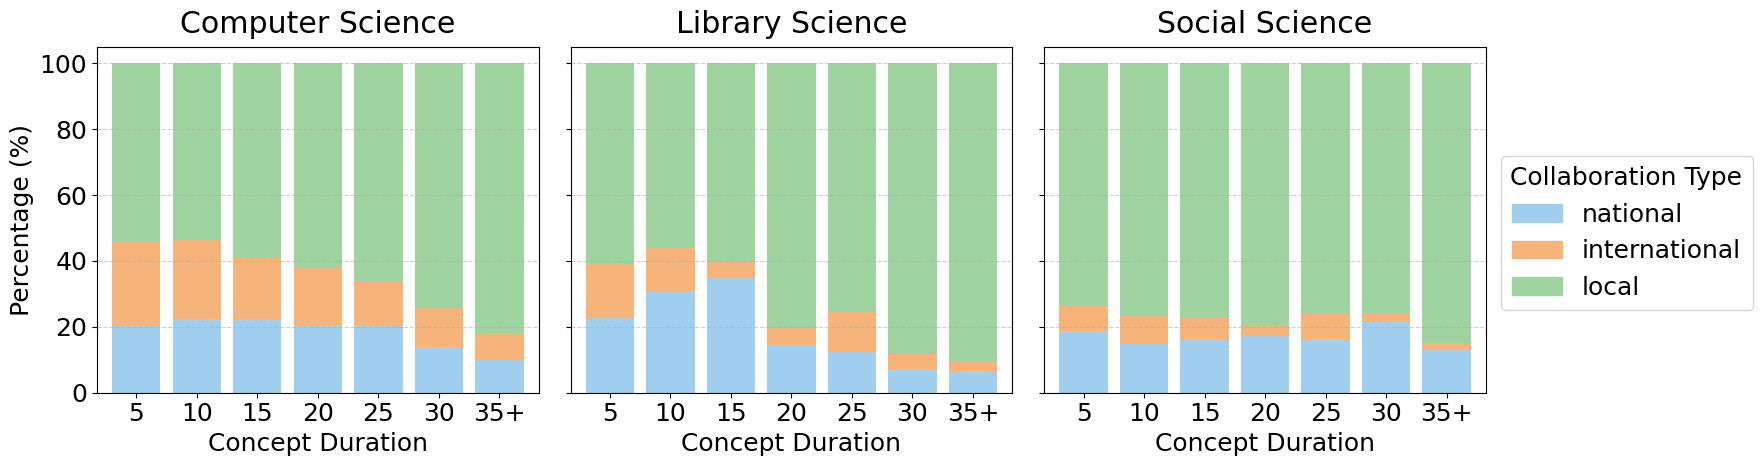

In [25]:
def plot_collaboration_by_height_three(df_list, titles=None, figsize=(18, 5), ncols=3):
    """
    Plot a stacked bar chart of the three DataFrames, grouped by height for their collaboration_type.
    They share a single legend, and each sub-figure can have a custom title.

    参数:
        df_list (list of pd.DataFrame): Three DataFrames, each with 'height' and 'collaboration_type'.
        titles (list of str, optional): Titles of the three subgraphs.
        figsize (tuple): Overall image size.
        ncols (int): The number of columns for the subgraph.
    """
    if len(df_list) != 3:
        raise ValueError("df_list must contain exactly three DataFrames.")

    if titles is None:
        titles = ["Dataset 1", "Dataset 2", "Dataset 3"]
    elif len(titles) != 3:
        raise ValueError("The titles field must contain three strings.")

    nrows = 1 if ncols == 3 else 3
    plt.rcParams["font.size"] = 18
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharey=True)
    if ncols == 1:
        axes = axes.flatten()
    else:
        axes = [axes] if ncols == 1 else axes

    colors = ["#a0ceef", "#f6b47a", "#9fd39f"]
    collaboration_order = ["national", "international", "local"]

    for i, (df, title) in enumerate(zip(df_list, titles)):
        ax = axes[i]
        df = df.copy()
        df["height_group"] = df["height"].apply(
            lambda x: "35+" if x > 30 else str(int(x))
        )
        count_table = (
            df.groupby(["height_group", "collaboration_type"])
            .size()
            .unstack(fill_value=0)
        )
        for ct in collaboration_order:
            if ct not in count_table.columns:
                count_table[ct] = 0
        count_table = count_table[collaboration_order]
        count_table_pct = count_table.div(count_table.sum(axis=1), axis=0) * 100

        # Sort by height_group (values ​​first, '35+' last).
        def sort_key(x):
            return (float("inf"), x) if x == "35+" else (int(x), x)

        count_table_pct = count_table_pct.sort_index(
            key=lambda idx: pd.Index([sort_key(x) for x in idx])
        )
        count_table_pct.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=colors,
            width=0.8,
            legend=False,
        )
        ax.set_title(title, pad=10)
        ax.set_xlabel("Concept Duration")
        ax.set_ylabel("Percentage (%)" if i == 0 else "")
        ax.tick_params(axis="x", rotation=0)
        ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Shared legend (placed on the right)
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[j], label=collaboration_order[j])
        for j in range(3)
    ]
    fig.legend(
        handles=handles,
        title="Collaboration Type",
        bbox_to_anchor=(0.99, 0.5),
        loc="center right",
    )
    plt.tight_layout(
        rect=[0, 0, 0.85, 1]
    )  # Leave space on the right side for the legend
    plt.savefig(f"./pic_for_paper/4.3 - Concept Duration.pdf")


plot_collaboration_by_height_three(
    [df_cs, df_lis, df_soci], ["Computer Science", "Library Science", "Social Science"]
)